# Clasificación de trabajos en HPC usando BNN-MLP (Clúster Kabré de CeNAT/CONARE Costa Rica)

## Introducción


### 👥 Integrantes del grupo

|  Nombre | Carné |
|---|---|
| Daniel Garbanzo | 2022117129 |
| Luis Carlos Navarro Todd| 2022212158 |
| Ricardo Shum Estrada | 2017144193 |


A continuación se presenta el trabajo de un modelo de clasificación con incertidumbre para optimización de trabajos Slurm en sistemas de computación de alto rendimiento (HPC), específicamente para el clúster Kabré de CeNAT/CONARE Costa Rica. El primer objetivo del trabajo es clasificar los trabajos del [dataset de trabajos de Kabré](https://raw.githubusercontent.com/DylanBC09/Project-1-CeNAT/refs/heads/main/dataset.csv) en completados y no completados. Además gracias a la naturaleza del MLP Bayesiano utilizado se puede cuantificar la incertidumbre.

Se trabajará con la metodología CRISP-DM, que consta de las siguientes fases:
| Fase | Actividad en este trabajo |
|---|---|
| **1. Business Understanding** | Descripción del problema · Pregunta analítica · Criterio de éxito medible · Justificación del algoritmo |
| **2. Data Understanding** | Carga del dataset (URL pública) · Shape, tipos, estadísticos · ≥2 gráficas |
| **3. Data Preparation** | Análisis de NaN y outliers · Limpieza  · Manejo de faltantes · Balanceo de Clases · Creación de X y y · Normalización de los datos |
| **4. Modeling** | Distancias L1 y L2 (Conceptos #3 y #4) · Implementación desde cero del algoritmo kNN (Combinaciones Lineales, Concepto #5) · Verificaciones numéricas intermedias|
| **5. Evaluation** | Cross-validation del hiperparámetro · Métricas calculadas manualmente · Comparación con baseline · Análisis de error · Visualización |
| **6. Deployment** | Interpretación en contexto del dataset · Limitaciones del modelo · Respuesta a la pregunta analítica |

---




## 1. Business Understanding

### Contexto

  Los clústeres de cómputo de alto rendimiento (HPC, *High Performance Computing*)
  son infraestructuras compartidas donde múltiples usuarios envían trabajos de cómputo intensivo. El gestor de colas **Slurm** (*Simple Linux Utility for Resource Management*) recibe estas solicitudes y las planifica según los recursos disponibles: CPUs, memoria, nodos y tiempo de ejecución.

  Cada trabajo enviado compite con otros por recursos limitados. El resultado final
  puedes ser:

  | Estado | Significado |
  |--------|-------------|
  | `COMPLETED` | El trabajo terminó exitosamente |
  | `FAILED` | El trabajo falló durante la ejecución |
  | `TIMEOUT` | El trabajo excedió su límite de tiempo configurado |
  | `CANCELLED` | El trabajo fue cancelado por el usuario o el sistema |

  ### El problema

  El dataset analizado corresponde a **229,466 trabajos** ejecutados en el clúster **Kabre** del Centro Nacional de Alta Tecnología (CeNAT) de Costa Rica entre los años 2024 a 2026, distribuidos en particiones como `andalan`, `dribe`, `kura` y `nukwa`, entre otras.

  La distribución de resultados revela un problema significativo:
NODE_FAIL 	73 	0.03
  | Estado | Trabajos | Porcentaje |
  |--------|----------|------------|
  | `FAILED` | 114,266 | 49.80% |
  | `COMPLETED` | 95,935 | 41.81% |
  | `CANCELLED` | 12,207 | 5.32% |
  | `TIMEOUT` | 6,985 | 3.04% |
  | `NODE_FAIL` | 73 | 0.03% |

  **El 49.8% de los trabajos fallan.** Esto representa un
  costo  significativo: tiempo de investigador desperdiciado, recursos computacionales
  consumidos
  sin resultado, y retrasos en proyectos científicos.

  ### Objetivo

  Este proyecto aborda el problema en dos etapas:

  1. **Predicción**: Predecir si un trabajo (*basado en propiedades como: CPUs solicitados, memoria, partición, límite de tiempo, prioridad,
     momento de envío*) será completado exitosamente (`COMPLETED`) o
  no.

  2. **Medición de Incertidumbre**: Para las predicciones hechas, generar un score de 
     **incertidumbre** para cuantificar la seguridad del modelo.
     
  ### Pregunta analítica

*"¿Es posible predecir con precisión si un trabajo en el clúster Kabré se completará exitosamente, y si no, qué cambios específicos en su configuración podrían aumentar esa probabilidad?"*

  La idea es que el sistema actúe como un asistente de diagnóstico previo al envío.

  > *"Tu trabajo ha sido diagnosticado como un fallo con baja incertidumbre. Por favor revisar configuración"*

  Esto permite al investigador considerar si está enviando alguna configuración mal antes de comprometer
  recursos,  reduciendo el ciclo de prueba y error que hoy es la norma en el uso de clústeres HPC.

  ### Criterio de éxito
  El éxito se medirá en dos niveles:
  1. **Predicción**: Un modelo de clasificación binaria con un F1-score de al menos 80% en un conjunto de prueba separado.
  2. **Incertidumbre**: Trabajos artificiales con tiempos de 0, con tiempos de 1 mes, sin memoria o con algún outlier fuerte deben ser catalogados como fallidos con baja incertidumbre.

  ### Enfoque técnico

  El clasificador se implementa con **Bayesian Neural Network Multi-Layer Perceptron**,
  eligiendo este algoritmo por su capacidad de cuantificar incertidumbre en el contexto de Kabré.

  ---

# 2. Data Understanding

In [1]:
# Kabré Env Fix
%env -u LD_LIBRARY_PATH
!echo $LD_LIBRARY_PATH

env: -u=LD_LIBRARY_PATH



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 4)
sns.set_theme(style='whitegrid', palette='muted')

# Carga del dataset (separador pipe)
df = pd.read_csv('data/sacct_out.csv', sep='|', parse_dates=['Submit'], low_memory=False)

print(f"Shape: {df.shape}")
display(df.head())

Shape: (229466, 12)


,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqMem,ReqNodes,ResvCPURAW,Submit,TimelimitRaw,Partition,Priority,QOS,State
0,3800474.0,4147584,1,100Mc,1,345743,2024-06-25 14:03:31,1440,nukwa-wide,7046,normal,TIMEOUT
1,0.0,4147968,1,100Mc,1,172857,2024-06-25 14:03:34,1440,nukwa-wide,7046,normal,TIMEOUT
2,3774906.0,4147392,1,100Mc,1,432175,2024-06-25 14:03:37,1440,nukwa-wide,7046,normal,TIMEOUT
3,3782559.0,4147536,1,100Mc,1,259290,2024-06-25 14:03:47,1440,nukwa-wide,7046,normal,TIMEOUT
4,3723128.0,4088688,1,100Mc,1,518590,2024-06-25 14:03:56,1440,nukwa-wide,7046,normal,COMPLETED


In [3]:
### 2.2 Tipos de datos y estadísticos descriptivos
print("=== Tipos de datos ===")
print(df.dtypes)
print(f"\n=== Estadísticos (variables numéricas) ===")
display(df.describe())

=== Tipos de datos ===
ConsumedEnergyRaw           float64
CPUTimeRAW                    int64
ReqCPUS                       int64
ReqMem                       object
ReqNodes                      int64
ResvCPURAW                    int64
Submit               datetime64[ns]
TimelimitRaw                 object
Partition                    object
Priority                      int64
QOS                          object
State                        object
dtype: object

=== Estadísticos (variables numéricas) ===


,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqNodes,ResvCPURAW,Submit,Priority
count,2.170720e+05,2.294660e+05,229466.000000,229466.000000,2.294660e+05,229466,229466.000000
mean,4.769963e+05,2.052787e+05,10.734383,1.033526,8.092876e+05,2025-09-27 02:04:15.083035904,3833.536315
min,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,2024-06-25 14:03:31,0.000000
25%,1.820000e+02,1.200000e+01,1.000000,1.000000,0.000000e+00,2025-06-10 19:18:22,1994.000000
50%,1.037000e+03,4.000000e+02,1.000000,1.000000,1.000000e+00,2026-01-14 03:16:39,2718.000000
75%,1.622625e+04,3.020000e+03,16.000000,1.000000,2.400000e+01,2026-02-02 23:02:53,4355.000000
max,8.045518e+08,6.856732e+08,1280.000000,18.000000,4.294967e+09,2026-06-08 23:56:09,16293.000000
std,5.461249e+06,4.459506e+06,39.738871,0.388295,5.251509e+07,NaN,2904.043496


### 2.3 Valores nulos y duplicados

In [4]:
nulls = df.isnull().sum()
nulls_pct = nulls / len(df) * 100
null_df = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_pct}).query('Nulos > 0')

if null_df.empty:
    print("No hay valores nulos en el dataset.")
else:
    display(null_df)

dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {dups} ({dups/len(df)*100:.2f}%)")

,Nulos,% Nulos
ConsumedEnergyRaw,12394,5.401236



Filas duplicadas: 11258 (4.91%)


### 2.4 Variable objetivo: distribución de `State`

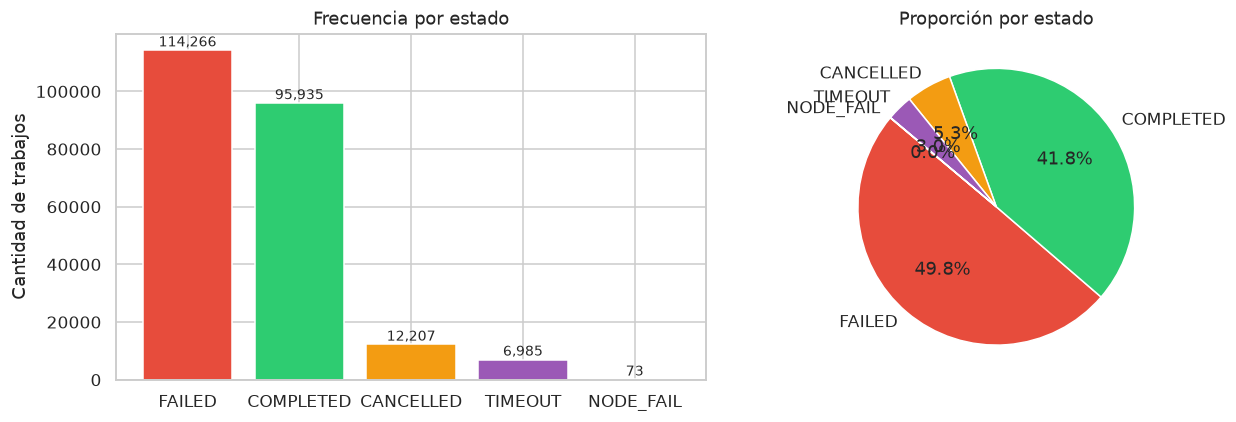


Tabla resumen:


,Trabajos,%
State,,
FAILED,114266,49.80
COMPLETED,95935,41.81
CANCELLED,12207,5.32
TIMEOUT,6985,3.04
NODE_FAIL,73,0.03


In [5]:
df['State'] = df['State'].str.split().str[0]  # Solo la primera palabra (ej. "COMPLETED" de "COMPLETED (0)")
state_counts = df['State'].value_counts()
state_pct = state_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = {'COMPLETED': '#2ecc71', 'FAILED': '#e74c3c', 'CANCELLED': '#f39c12', 'TIMEOUT': '#9b59b6'}
bar_colors = [colors.get(s, '#95a5a6') for s in state_counts.index]
axes[0].bar(state_counts.index, state_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Frecuencia por estado')
axes[0].set_ylabel('Cantidad de trabajos')
for bar, val in zip(axes[0].patches, state_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie
axes[1].pie(state_pct.values, labels=state_pct.index,
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[1].set_title('Proporción por estado')

plt.tight_layout()
plt.show()

print("\nTabla resumen:")
display(pd.DataFrame({'Trabajos': state_counts, '%': state_pct.round(2)}))

### 2.5 Variables categóricas: `Partition` y `QOS`

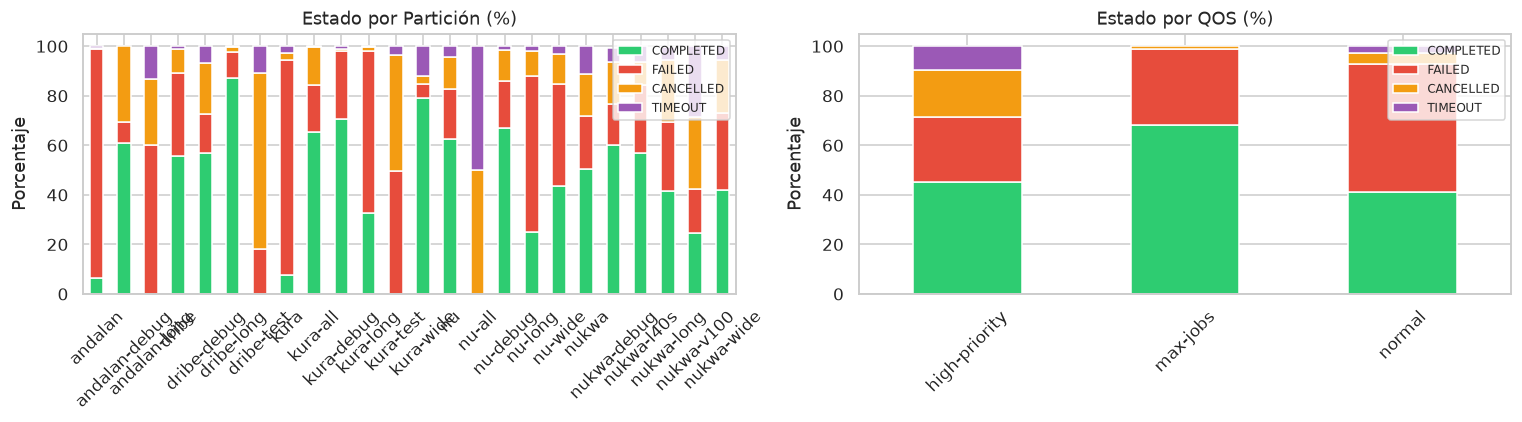

Trabajos por Partición:


,Trabajos
Partition,
kura,71755
dribe-long,39971
dribe,22114
kura-long,17661
andalan,16764
kura-wide,16236
nukwa-l40s,11690
nukwa,6643
nukwa-long,5940



Trabajos por QOS:


,Trabajos
QOS,
normal,214466
high-priority,12815
max-jobs,2185


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Partición
part_state = df.groupby(['Partition', 'State']).size().unstack(fill_value=0)
part_state_pct = part_state.div(part_state.sum(axis=1), axis=0) * 100
part_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[0].set_title('Estado por Partición (%)')
axes[0].set_ylabel('Porcentaje')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# QOS
qos_state = df.groupby(['QOS', 'State']).size().unstack(fill_value=0)
qos_state_pct = qos_state.div(qos_state.sum(axis=1), axis=0) * 100
qos_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Estado por QOS (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Trabajos por Partición:")
display(df['Partition'].value_counts().to_frame('Trabajos'))
print("\nTrabajos por QOS:")
display(df['QOS'].value_counts().to_frame('Trabajos'))

### 2.6 Variables numéricas: distribuciones y outliers

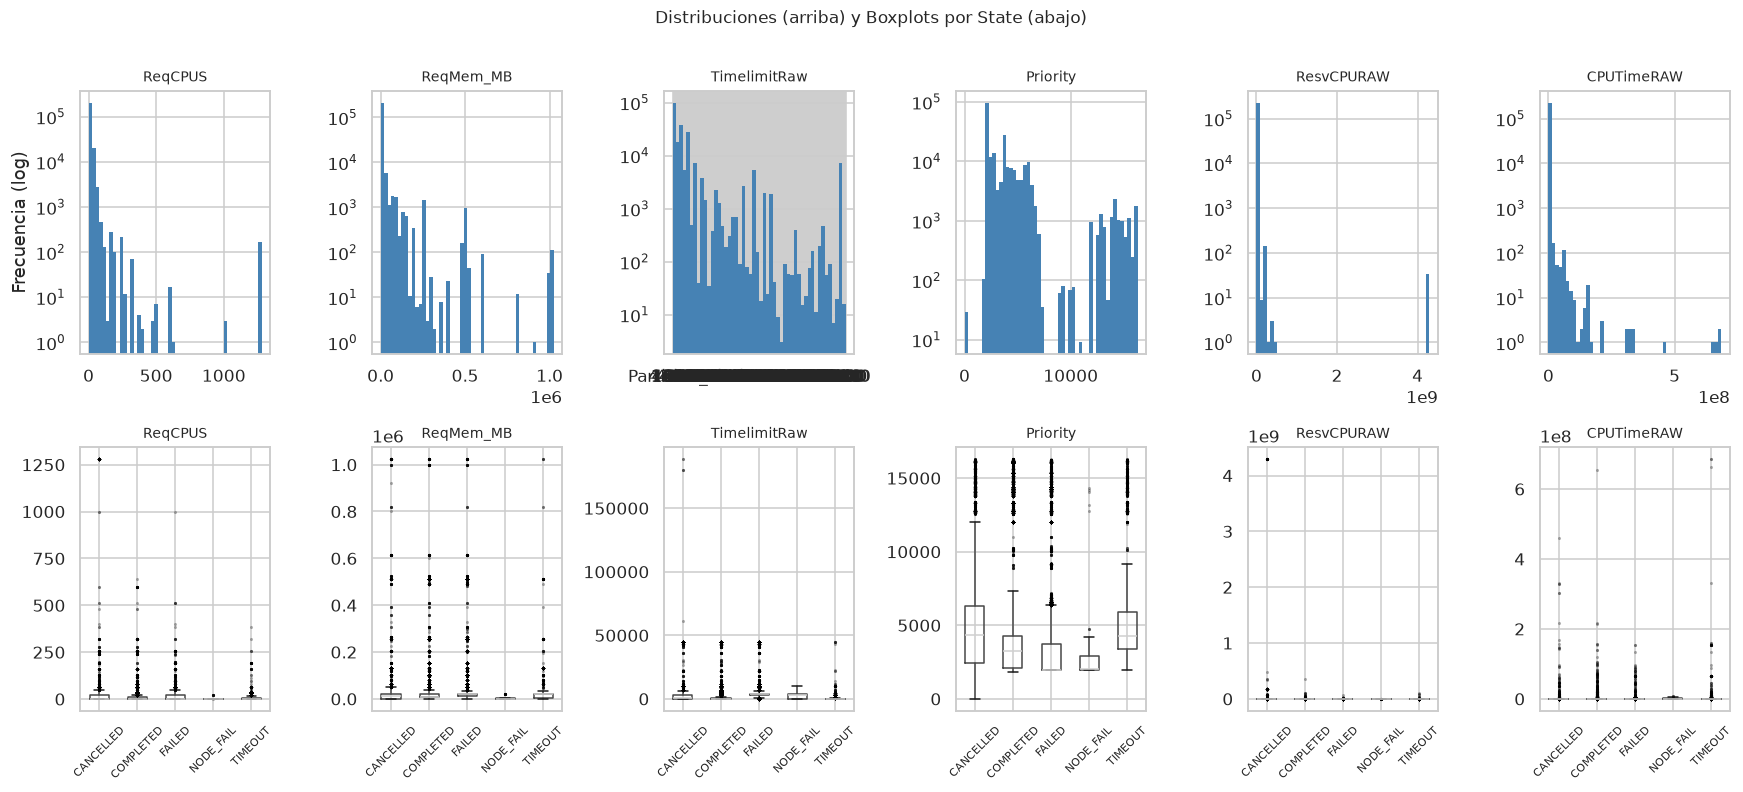

In [7]:
# Parsear ReqMem: convierte '100Mc' -> 100 MB/core, '4Gn' -> 4096 MB/nodo, etc.
def parse_reqmem(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.endswith('Mc'):
        return float(val[:-2])          # MB por core
    elif val.endswith('Mn'):
        return float(val[:-2])          # MB por nodo
    elif val.endswith('Gc'):
        return float(val[:-2]) * 1024   # GB por core -> MB
    elif val.endswith('Gn'):
        return float(val[:-2]) * 1024   # GB por nodo -> MB
    else:
        try:
            return float(val)
        except:
            return np.nan

df['ReqMem_MB'] = df['ReqMem'].apply(parse_reqmem)

num_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitRaw', 'Priority', 'ResvCPURAW', 'CPUTimeRAW']

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 7))

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    if col == 'TimelimitRaw':
        data = data.astype(str)
    # Histograma (log scale)
    axes[0, i].hist(data, bins=50, color='steelblue', edgecolor='none', log=True)
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Frecuencia (log)' if i == 0 else '')

    # Boxplot por estado
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    plot_df = df.loc[numeric_col.notna(), ['State']].copy()
    plot_df[col] = numeric_col[numeric_col.notna()]
    plot_df.boxplot(column=col, by='State', ax=axes[1, i],
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[1, i].set_title(col, fontsize=9)
    axes[1, i].set_xlabel('')
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('')
fig.text(0.5, 1.01, 'Distribuciones (arriba) y Boxplots por State (abajo)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# Parece haber data no numérica en TimelimitRaw
print("Valores únicos en TimelimitRaw:")
display(df['TimelimitRaw'].unique())

Valores únicos en TimelimitRaw:


array(['1440', '4200', '60', '44640', '300', '4320', '10080', '10140',
       '480', '40', '240', '120', '5760', '9600', '180', '720', '10',
       'Partition_Limit', '30240', '700', '350', '2880', '8640', '4',
       '128', '479', '4140', '2640', '744', '12000', '10320', '7200',
       '6000', '600', '70', '168', '3600', '3540', '144', '360', '1444',
       '4800', '2000', '24', '30', '11520', '1040', '5400', '2160',
       '2790', '3840', '43200', '1210', '4680', '3645', '3000', '42000',
       '14640', '4090', '9840', '2925', '540', '420', '50', '21600',
       '1200', '610', '9000', '4620', '900', '3360', '5', '1', '11',
       '1811', '61', '31', '4080', '1800', '14400', '4290', '20', '44400',
       '1380', '1439', '18000', '100', '1500', '10020', '43800', '4330',
       '4270', '4440', '2', '3130', '64', '23040', '36000', '90', '1260',
       '2400', '44580', '4260', '10440', '4210', '320', '5700',
       'UNLIMITED', '7720', '246', '5940', '6', '481', '3240', '45',
       '9960

### 2.7 Análisis temporal: envíos por mes y hora del día

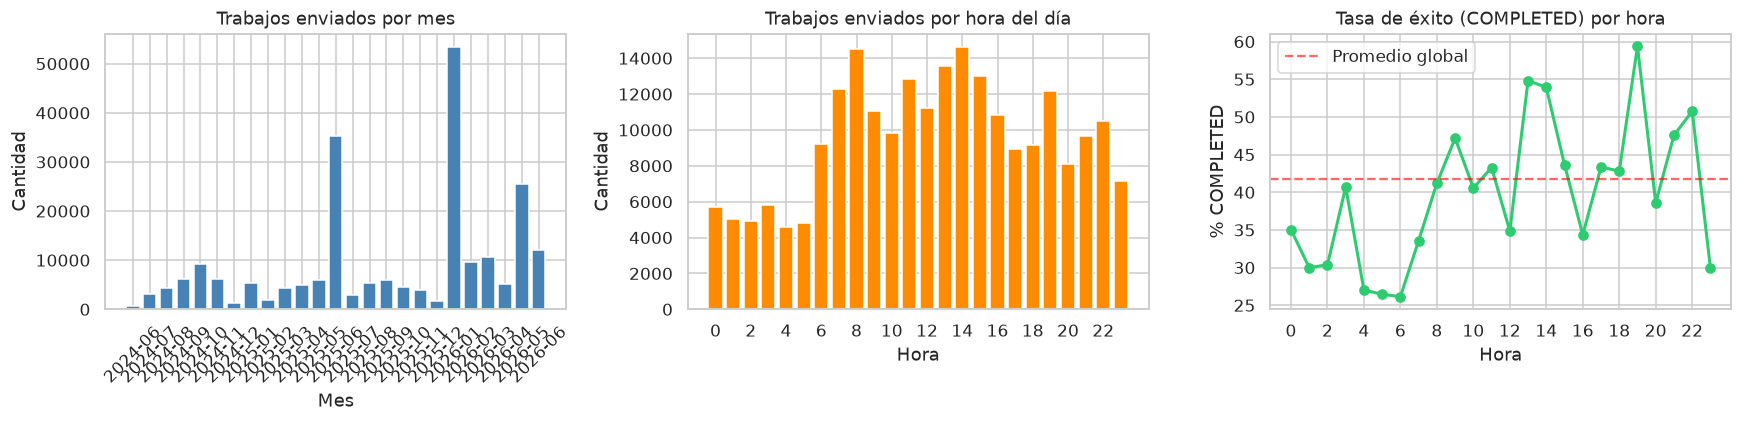

In [9]:
df['submit_month'] = df['Submit'].dt.to_period('M')
df['submit_hour'] = df['Submit'].dt.hour
df['submit_dow'] = df['Submit'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trabajos por mes
month_counts = df.groupby('submit_month').size()
axes[0].bar(month_counts.index.astype(str), month_counts.values, color='steelblue')
axes[0].set_title('Trabajos enviados por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Trabajos por hora del día
hour_counts = df.groupby('submit_hour').size()
axes[1].bar(hour_counts.index, hour_counts.values, color='darkorange')
axes[1].set_title('Trabajos enviados por hora del día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(range(0, 24, 2))

# Tasa de completado por hora del día
completed_by_hour = df[df['State'] == 'COMPLETED'].groupby('submit_hour').size()
total_by_hour = df.groupby('submit_hour').size()
success_rate = (completed_by_hour / total_by_hour * 100).fillna(0)
axes[2].plot(success_rate.index, success_rate.values, marker='o', color='#2ecc71', linewidth=2)
axes[2].set_title('Tasa de éxito (COMPLETED) por hora')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('% COMPLETED')
axes[2].set_xticks(range(0, 24, 2))
axes[2].axhline(df['State'].eq('COMPLETED').mean() * 100, color='red',
                linestyle='--', alpha=0.6, label='Promedio global')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.8 Resumen de hallazgos del EDA

| Hallazgo | Detalle |
|---|---|
| **Desbalance de clases** | Solo el ~49% de trabajos son `FAILED`; el ~41% son `COMPLETED`. Se requiere manejo de desbalance en la preparación. |
| **Partición crítica** | Las tasas de éxito varían mucho por partición — algunas tienen >60% de éxito, otras casi 0%. La partición es feature clave. Además se deberían unir por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe) |
| **Tasa de éxito por hora** | Los trabajos suelen tener una tasa de éxito más alta durante ciertas horas del día. |
| **Nulos** | Algunas columnas numéricas tienen valores nulos que deben ser manejados (imputación o eliminación). |
| **TimelimitRaw con valores no numéricos** | Aparecen valores no numéricos en la columna `TimelimitRaw` que deben ser tratados. |
| **Trabajos enviados por mes** | Aparecen una cantidad enorme de trabajos en el mes de diciembre, 2025. Podrían ser varios trabajos cortos que estén generando ruido. |

# 3. Data Preparation

### 3.1 Limpieza de datos

#### 3.1.1 Nulos y Duplicados


In [10]:
# Remover nulos y duplicados
print(f"Shape original: {df.shape}")
print(f"Nulos totales originales: {df.isnull().sum().sum()}")
print(f"Duplicados originales: {df.duplicated().sum()}")

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("\nDespués de limpieza:")
print(f"Shape: {df.shape}")
print(f"Nulos totales: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")


Shape original: (229466, 16)
Nulos totales originales: 12516
Duplicados originales: 11258

Después de limpieza:
Shape: (207050, 16)
Nulos totales: 0
Duplicados: 0


#### 3.1.2 Particiones Estandarizadas

Se unirán las particiones por tipo para reducir la cardinalidad y mejorar la generalización del modelo. Por ejemplo, `andalan`, `andalan-long` y `andalan-debug` se agruparán como `Andalán`. Esto también ayuda a mitigar el problema de particiones con muy pocos ejemplos.

In [11]:
df['PartitionGroup'] = df['Partition'].str.split('-').str[0].str.capitalize()  # Unificar por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe)
print("Particiones estandarizadas:")
display(df['PartitionGroup'].value_counts().to_frame('Trabajos'))

Particiones estandarizadas:


,Trabajos
PartitionGroup,
Kura,99602
Dribe,58439
Nukwa,23892
Andalan,16229
Nu,8888


#### 3.1.3 Manejo de valores no numéricos en `TimelimitRaw`

In [12]:
# Parsear TimelimitRaw según partición:
# - Si es numérico, se conserva.
# - Si viene como "Partition_Limit" (u otro no numérico), se reemplaza por esto:
# nukwa	GPU	1	24 horas
# nukwa-debug	GPU	1	4 horas
# nukwa-wide	GPU	2	24 horas
# nukwa-long	GPU	1	48 horas
# dribe-long	Xeon	1	744 horas
# dribe	Xeon	1	72 horas
# dribe-debug	Xeon	1	8 horas
# kurá-debug	Xeon	1	8 horas
# kurá-wide	Xeon	4	24 horas
# kurá	Xeon	1	72 horas
# kurá-long	Xeon	1	168 horas
# Andalan y Nu igual que Kurá
def parse_timelimit(val, partition):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.isdigit():
        return float(val)
    mapping = {
        'nukwa': 24 * 3600,
        'nukwa-debug': 4 * 3600,
        'nukwa-wide': 24 * 3600,
        'nukwa-long': 48 * 3600,
        'dribe-long': 744 * 3600,
        'dribe': 72 * 3600,
        'dribe-debug': 8 * 3600,
        'kurá-debug': 8 * 3600,
        'kurá-wide': 24 * 3600,
        'kurá': 72 * 3600,
        'kura': 72 * 3600,
        'kurá-long': 168 * 3600,
        'andalan': 72 * 3600,
        'andalan-debug': 8 * 3600,
        'andalan-long': 168 * 3600,
        'nu': 72 * 3600,
        'nu-debug': 8 * 3600,
        'nu-long': 168 * 3600
    }
    for key in mapping:
        if key in partition.lower():
            return mapping[key]
    return np.nan

df['TimelimitSec'] = df.apply(lambda row: parse_timelimit(row['TimelimitRaw'], row['Partition']), axis=1)
print("TimelimitRaw parseado:")
display(df[['TimelimitRaw', 'Partition', 'TimelimitSec']].head(10))

TimelimitRaw parseado:


,TimelimitRaw,Partition,TimelimitSec
0,1440,nukwa-wide,1440.0
1,1440,nukwa-wide,1440.0
2,1440,nukwa-wide,1440.0
3,1440,nukwa-wide,1440.0
4,1440,nukwa-wide,1440.0
5,4200,andalan,4200.0
6,4200,andalan,4200.0
7,1440,kura,1440.0
8,44640,dribe-long,44640.0
9,1440,kura,1440.0


### 3.2 Correlaciones entre variables numéricas

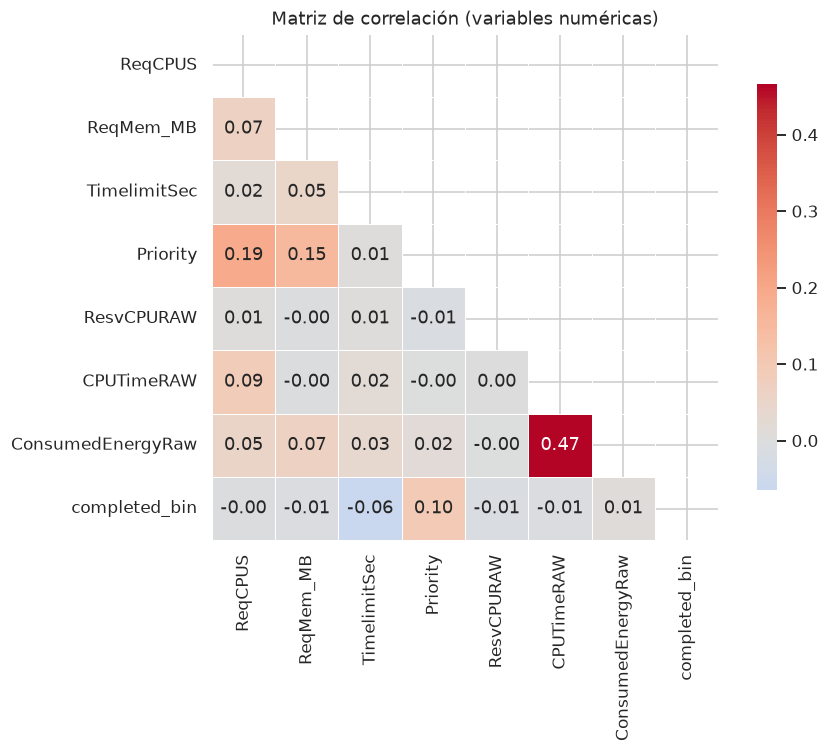


Correlación con 'completed_bin':


Priority             0.096691
TimelimitSec        -0.064057
ResvCPURAW          -0.011195
CPUTimeRAW          -0.009893
ReqMem_MB           -0.008687
ConsumedEnergyRaw    0.008662
ReqCPUS             -0.002794
Name: completed_bin, dtype: float64

In [13]:
# Variable objetivo binaria para correlación
df['completed_bin'] = (df['State'] == 'COMPLETED').astype(int)

corr_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority',
             'ResvCPURAW', 'CPUTimeRAW', 'ConsumedEnergyRaw', 'completed_bin']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
print("\nCorrelación con 'completed_bin':")
display(corr_matrix['completed_bin'].drop('completed_bin').sort_values(key=abs, ascending=False))

### 3.3 Análisis de outliers con IQR

In [14]:
outlier_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority', 'CPUTimeRAW']

rows = []
for col in outlier_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    lb = max(lb, 0)  # No permitir límites negativos
    n_out = ((data < lb) | (data > ub)).sum()
    rows.append({'Columna': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                 'Límite inferior': lb, 'Límite superior': ub,
                 'Outliers': n_out, '% Outliers': round(n_out / len(data) * 100, 2)})

outlier_df = pd.DataFrame(rows).set_index('Columna')
display(outlier_df)

plt.tight_layout()
plt.show()

,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% Outliers
Columna,,,,,,,
ReqCPUS,1.0,10.0,9.0,0,23.5,31485,15.21
ReqMem_MB,2000.0,20000.0,18000.0,0,47000.0,8128,3.93
TimelimitSec,240.0,4200.0,3960.0,0,10140.0,5757,2.78
Priority,1994.0,4290.0,2296.0,0,7734.0,10531,5.09
CPUTimeRAW,20.0,2124.0,2104.0,0,5280.0,39941,19.29


<Figure size 1100x440 with 0 Axes>

Se pueden observar varios outliers, sin embargo, son datos que se encuentran dentro de lo esperado para un clúster HPC, por lo que se mantendrán para preservar la variabilidad real del dataset. 

### 3.4 One-hot encoding de variables categóricas

In [15]:
def one_hot(value: str, categories: list[str]) -> list[float]:
    return [1.0 if value.strip() == c else 0.0 for c in categories]

### 3.5 Creación de matrices de características (X) y etiquetas (y)

En la siguiente celda se muestra la creación de las matrices de características (X) y etiquetas (y) a partir del dataset limpio. La matriz `X` contiene las features numéricas y las variables categóricas codificadas, mientras que la matriz `y` contiene la variable objetivo binaria que indica si el trabajo fue completado exitosamente o no. Los datos categóricos se codifican utilizando one-hot encoding, lo que permite al modelo interpretar cada categoría como una dimensión separada en el espacio de características.

Después del tratamiento actual, las distribuciones son las siguientes:

In [16]:
PARTITION_GROUPS = df['PartitionGroup'].unique().tolist()
QOS_CATEGORIES = df['QOS'].unique().tolist()

def build_features(row: dict) -> list[float] | None:
    """
    Returns a feature vector or None if the row has critical missing values.

    Feature vector layout (14 dims):
      [0]  ReqCPUS
      [1]  ReqMem_MB
      [2]  ReqNodes
      [3]  ResvCPURAW
      [4]  TimelimitSec
      [5]  Priority
      [6]  submit_hour
      [7]  submit_dow
      [8..12]  one-hot Partition  (5 categories)
      [13..15]  one-hot QOS        (3 categories)
    """
    try:
        req_cpus = float(row["ReqCPUS"])
        req_mem = float(row["ReqMem_MB"])
        req_nodes = float(row["ReqNodes"])
        resv_cpu = float(row["ResvCPURAW"])
        timelimit = float(row["TimelimitSec"])
        priority = float(row["Priority"])
        hour, dow = float(row["submit_hour"]), float(row["Submit"].dayofweek)
    except (ValueError, KeyError):
        print(f"Fila con datos faltantes o no numéricos: {row.get('JobID', 'N/A')}")
        return None

    vec = [
        req_cpus,
        req_mem,
        req_nodes,
        resv_cpu,
        timelimit,
        priority,
        float(hour),
        float(dow),
        *one_hot(row["PartitionGroup"], PARTITION_GROUPS),
        *one_hot(row["QOS"], QOS_CATEGORIES),
    ]
    return vec

In [17]:
X_raw, y_raw = [], df['State'].apply(lambda s: 1 if s.strip() == 'COMPLETED' else 0).tolist()

for _, row in df.iterrows():
    features = build_features(row)
    if features is not None:
        X_raw.append(features)

print(f"Total muestras con features: {len(X_raw)}")


Total muestras con features: 207050


### 3.6 División del Dataset

In [18]:
from sklearn.model_selection import train_test_split
# 75% Train, 15% Test, 10% Val
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.25, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_raw, y_raw, test_size=0.4, random_state=42)

### 3.7 Desbalanceo de Clases

In [22]:
# from imblearn.combine import SMOTEENN
from collections import Counter

# smote_enn = SMOTEENN(random_state=0)
# X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)
# print(sorted(Counter(y_resampled).items()))

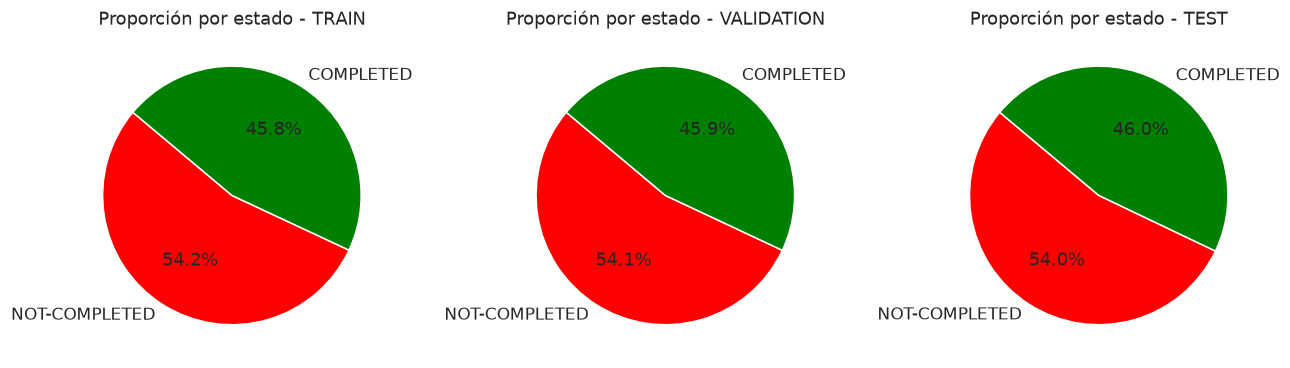

In [23]:
y_resampled_count = [item[1] for item in sorted(Counter(y_train).items())]
y_val_count = [item[1] for item in sorted(Counter(y_val).items())]
y_test_count = [item[1] for item in sorted(Counter(y_test).items())]

bar_colors = ["red", "green"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Pie 1
axes[0].pie(y_resampled_count, labels=["NOT-COMPLETED", "COMPLETED"],
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[0].set_title('Proporción por estado - TRAIN')

# Pie 2
axes[1].pie(y_val_count, labels=["NOT-COMPLETED", "COMPLETED"],
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[1].set_title('Proporción por estado - VALIDATION')

# Pie 3
axes[2].pie(y_test_count, labels=["NOT-COMPLETED", "COMPLETED"],
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[2].set_title('Proporción por estado - TEST')

plt.tight_layout()
plt.show()


### 3.8 Normalización de Datos

In [25]:
from sklearn.preprocessing import StandardScaler
transformer = StandardScaler().fit(X_train)  # fit does nothing.
X_resampled = transformer.transform(X_train)

In [27]:
import jax.numpy as jnp
""" Pasar a jax numpy """
X_train, y_train = np.array(X_resampled), jnp.array(y_train, dtype=jnp.int8)
X_val, y_val = jnp.array(X_val), jnp.array(y_val, dtype=jnp.int8)
X_test, y_test = jnp.array(X_test), jnp.array(y_test, dtype=jnp.int8)


## 4. Modeling (kNN)

### 4.1 Implementación de distancias L1 (Manhattan) y L2 (Euclidiana)

In [25]:
# Distancias por batch (vectorizadas) L2 y L1
def _euclidean_batch(query: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    """||query - x||₂  for every row x in X_train."""
    diff = X_train - query          # (n, d)
    return np.sqrt((diff * diff).sum(axis=1))

def _manhattan_batch(query: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    """Σ|query_i - x_i|  for every row x in X_train."""
    return np.abs(X_train - query).sum(axis=1)

### 4.2 Implementación del algoritmo kNN desde cero

In [26]:
from collections import Counter
import jax.numpy as jnp

class KNNClassifier:
    """
    k-Nearest Neighbours classifier.

    Parameters
    ----------
    k : int
        Number of neighbours to use.
    metric : str
        Distance metric: "euclidean", "manhattan".
    weighted : bool
        If True, neighbours vote weighted by 1/distance.
        If False, plain majority vote.
    """

    def __init__(
        self,
        k: int = 5,
        metric: str = "euclidean",
        weighted: bool = False,
    ):
        if metric not in ("euclidean", "manhattan"):
            raise ValueError(f"Unknown metric '{metric}'.")
        self.k = k
        self.metric = metric
        self.weighted = weighted
        self._X: jnp.ndarray | None = None
        self._y: jnp.ndarray | None = None

    # ------------------------------------------------------------------ #
    def fit(self, X, y) -> "KNNClassifier":
        """Store training data as numpy arrays (lazy learning)."""
        self._X = jnp.asarray(X, dtype=jnp.float32)
        self._y = jnp.asarray(y, dtype=jnp.int32)
        return self

    # ------------------------------------------------------------------ #
    def _distances(self, query: jnp.ndarray) -> jnp.ndarray:
        if self.metric == "euclidean":
            return _euclidean_batch(query, self._X)
        if self.metric == "manhattan":
            return _manhattan_batch(query, self._X)
        raise NotImplementedError("Metric not implemented yet.")

    def _get_neighbours(self, query: jnp.ndarray):
        """
        Returns (distances, labels) arrays for the k nearest neighbours,
        sorted ascending by distance.
        """
        dists = self._distances(query)
        # argpartition gives the k smallest indices (unsorted), then sort them
        k_idx = jnp.argpartition(dists, self.k)[: self.k]
        k_idx = k_idx[jnp.argsort(dists[k_idx])]
        return dists[k_idx], self._y[k_idx]

    # ------------------------------------------------------------------ #
    def predict_one(self, query) -> int:
        q = jnp.asarray(query, dtype=jnp.float32)
        dists, labels = self._get_neighbours(q)
        if self.weighted:
            weights = 1.0 / (dists + 1e-9)
            votes: dict[int, float] = {}
            for w, lbl in zip(weights, labels):
                votes[int(lbl)] = votes.get(int(lbl), 0.0) + float(w)
            return max(votes, key=votes.__getitem__)
        else:
            return int(Counter(labels.tolist()).most_common(1)[0][0])

    def predict(self, X) -> list[int]:
        X_arr = jnp.asarray(X, dtype=jnp.float32)
        return [self.predict_one(row) for row in X_arr]

    # ------------------------------------------------------------------ #
    def predict_proba_one(self, query) -> dict[int, float]:
        """Returns {class: probability} for the query point."""
        q = jnp.asarray(query, dtype=jnp.float32)
        dists, labels = self._get_neighbours(q)
        if self.weighted:
            weights = 1.0 / (dists + 1e-9)
            votes: dict[int, float] = {}
            for w, lbl in zip(weights, labels):
                votes[int(lbl)] = votes.get(int(lbl), 0.0) + float(w)
            total = sum(votes.values())
            return {cls: v / total for cls, v in votes.items()}
        else:
            total = len(labels)
            counts: dict[int, int] = {}
            for lbl in labels:
                counts[int(lbl)] = counts.get(int(lbl), 0) + 1
            return {cls: cnt / total for cls, cnt in counts.items()}

    def predict_proba(self, X) -> list[dict[int, float]]:
        X_arr = jnp.asarray(X, dtype=jnp.float32)
        return [self.predict_proba_one(row) for row in X_arr]

    # ------------------------------------------------------------------ #
    def get_neighbours_for(self, query) -> list[tuple[float, int]]:
        """Returns k nearest (distance, label) pairs sorted ascending."""
        q = jnp.asarray(query, dtype=jnp.float32)
        dists, labels = self._get_neighbours(q)
        return list(zip(dists.tolist(), labels.tolist()))

### 4.3 Fit y predict del modelo kNN

In [27]:
kNN = KNNClassifier(k=5, metric="euclidean", weighted=False)
kNN.fit(X_train, y_train)
kNN_predictions = kNN.predict(X_test)

In [28]:
print(f"Predicciones kNN (primeros 20): {kNN_predictions[:20]}")
print(f"Labels reales (primeros 20)   : {y_test[:20]}")

Predicciones kNN (primeros 20): [0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0]
Labels reales (primeros 20)   : [0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0]


## 5. Modeling (BNN-MLP)

### 5.1 Modelo en Flax y Numpyro

In [28]:
import jax
import jax.numpy as jnp
from jax import random, vmap
import flax.linen as nn
from flax.training import train_state
import optax
import numpyro
import numpyro.distributions as dist
from numpyro import handlers
from numpyro.infer import MCMC, HMC, SVI, Trace_ELBO, Predictive, NUTS, TraceMeanField_ELBO
from numpyro.infer.autoguide import AutoNormal
import time
import os

In [29]:
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


### Concepto #1 del Curso: Modelos Probabilísticos y Distribuciones como Pesos

Este concepto está implícito en el uso de priors normales sobre los pesos de la red. En una BNN, cada peso deja de ser un valor fijo y pasa a modelarse como una variable aleatoria, por lo que la predicción final no es un único número, sino una distribución sobre salidas posibles. Eso permite capturar incertidumbre epistemica: si el modelo ve un job muy distinto a los del entrenamiento, su confianza debería disminuir.

En este notebook, esa idea se refleja en la definición de `bayesian_mlp_model`, donde los parámetros `w1`, `b1`, `w2`, `b2`, `w3` y `b3` se muestrean desde distribuciones `Normal(0, 1)` antes de calcular los logits. Esa formulación es la base para obtener predicciones con incertidumbre en la fase de evaluación.

### Concepto #2 del Curso: MLE y MAP

MLE (*Maximum Likelihood Estimation*) busca los parámetros que maximizan la probabilidad de observar los datos. En cambio, MAP (*Maximum A Posteriori*) incorpora un prior y maximiza la probabilidad posterior, es decir, combina evidencia de los datos con conocimiento previo sobre los pesos.

En este notebook, la formulación bayesiana se acerca a MAP porque los pesos tienen priors `Normal(0, 1)` y luego se ajustan con inferencia variacional. La guía `AutoNormal` aprende una aproximación tractable al posterior, lo que permite usar SVI para entrenar el modelo sin resolver la integral exacta del posterior.

### Concepto #3 del Curso: ELBO

El ELBO (*Evidence Lower Bound*) es la función objetivo de la inferencia variacional. Su idea central es equilibrar dos términos: explicar bien los datos observados y mantener la aproximación del posterior cerca del prior para evitar soluciones demasiado complejas.

En forma conceptual, maximizar el ELBO equivale a encontrar una buena aproximación del posterior sin pagar el costo de calcularlo exactamente. En este notebook eso se implementa con `Trace_ELBO()` dentro de `SVI`, y por eso la curva de pérdida que se grafica después representa directamente el progreso de esa optimización variacional.

In [38]:
"""
Bayesian MLP con Numpyro y Flax
Arquitectura: 16 → 64 → 32 → 2 (classes)
"""
hidden_dims=(64, 32, 16)
num_classes=2
 
# ============================================================================
# 2. MODELO BAYESIANO CON NUMPYRO
# ============================================================================
 
def bayesian_mlp_model(x_batch, y_batch=None):
    """
    Modelo probabilístico Bayesiano.
    
    Estructura:
    - Priors sobre pesos: Normal(0, 1) para inicialización
    - Likelihood: Categorical con softmax
    """
    batch_size = x_batch.shape[0]
    input_dim = x_batch.shape[1]
    
    # Priors sobre pesos (más estrictos para regularización)
    prior_scale = 0.5
    
    # Layer 1: (16, 64)
    w1 = numpyro.sample('w1', dist.Normal(0, prior_scale).expand([input_dim, hidden_dims[0]]))
    b1 = numpyro.sample('b1', dist.Normal(0, prior_scale).expand([hidden_dims[0]]))
    
    # Layer 2: (64, 32)
    w2 = numpyro.sample('w2', dist.Normal(0, prior_scale).expand([hidden_dims[0], hidden_dims[1]]))
    b2 = numpyro.sample('b2', dist.Normal(0, prior_scale).expand([hidden_dims[1]]))
    
    # Output Layer: (32, 2)
    w3 = numpyro.sample('w3', dist.Normal(0, prior_scale).expand([hidden_dims[1], num_classes]))
    b3 = numpyro.sample('b3', dist.Normal(0, prior_scale).expand([num_classes]))
    
    # Forward pass (manual para control total)
    z1 = jnp.dot(x_batch, w1) + b1  # [batch, 64]
    a1 = nn.relu(z1)
    
    z2 = jnp.dot(a1, w2) + b2       # [64, 32]
    a2 = nn.relu(z2)
    
    logits = jnp.dot(a2, w3) + b3   # [16, 2]
    
    # Likelihood
    with numpyro.plate('data', batch_size):
        numpyro.sample('y', dist.Categorical(logits=logits), obs=y_batch)


In [39]:
hidden_dims=(64, 32, 16)
num_classes=2

def manual_guide(x_batch, y_batch=None):
    """Variational guide: Normal independientes para cada peso"""
    input_dim = x_batch.shape[1]

    
    # ======= Layer 1: (16,64) =============
    w1_loc = numpyro.param('w1_loc', jnp.zeros((input_dim, hidden_dims[0])))
    w1_scale = numpyro.param('w1_scale', jnp.ones((input_dim, hidden_dims[0])), 
                             constraint=dist.constraints.positive)
    w1 = numpyro.sample('w1', dist.Normal(w1_loc, w1_scale))
    
    b1_loc = numpyro.param('b1_loc', jnp.zeros(hidden_dims[0]))
    b1_scale = numpyro.param('b1_scale', 0.1 * jnp.ones(hidden_dims[0]),
                             constraint=dist.constraints.positive)
    b1 = numpyro.sample('b1', dist.Normal(b1_loc, b1_scale))

    
    # ======= Layer 2: (64,32) =============
    w2_loc = numpyro.param('w2_loc', jnp.zeros((hidden_dims[0], hidden_dims[1])))
    w2_scale = numpyro.param('w2_scale', jnp.ones((hidden_dims[0], hidden_dims[1])),
                             constraint=dist.constraints.positive)
    w2 = numpyro.sample('w2', dist.Normal(w2_loc, w2_scale))
    
    b2_loc = numpyro.param('b2_loc', jnp.zeros(hidden_dims[1]))
    b2_scale = numpyro.param('b2_scale', 0.1 * jnp.ones(hidden_dims[1]),
                             constraint=dist.constraints.positive)
    b2 = numpyro.sample('b2', dist.Normal(b2_loc, b2_scale))

    
    # ======= Layer 3: (32,2) =============
    w3_loc = numpyro.param('w3_loc', jnp.zeros((hidden_dims[1], num_classes)))
    w3_scale = numpyro.param('w3_scale', jnp.ones((hidden_dims[1], num_classes)),
                             constraint=dist.constraints.positive)
    w3 = numpyro.sample('w3', dist.Normal(w3_loc, w3_scale))
    
    b3_loc = numpyro.param('b3_loc', jnp.zeros(num_classes))
    b3_scale = numpyro.param('b3_scale', 0.1 * jnp.ones(num_classes),
                             constraint=dist.constraints.positive)
    b3 = numpyro.sample('b3', dist.Normal(b3_loc, b3_scale))

### 5.2 Entrenar Modelo

#### 5.2.1 Métricas

In [40]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    accuracy_score
)

#### 5.2.2 Inferencia sin Incertidumbre

In [41]:
def predict(model, rng_key, samples, X):
    model = handlers.substitute(handlers.seed(model, rng_key), samples)
    model_trace = handlers.trace(model).get_trace(X, None)
    return model_trace["y"]["value"]


def _posterior_predictive_probs(X, guide, svi, svi_state, num_samples=1):
    params = svi.get_params(svi_state)
    predictive = Predictive(
        model=bayesian_mlp_model,
        guide=guide,
        params=params,
        num_samples=num_samples,
    )
    key = random.PRNGKey(0)
    samples = predictive(key, X, None)
    y_samples = samples["y"]
    one_hot_samples = jax.nn.one_hot(y_samples, num_classes=2)
    probs_mean = jnp.mean(one_hot_samples, axis=0)
    return probs_mean


def predict_simple(X, svi, svi_state):
    """Predicción puntual usando el posterior variacional entrenado."""
    return _posterior_predictive_probs(X, svi, svi_state, num_samples=1)


def predict_svi(X, svi, svi_state, model, guide):
    """Predicción probabilística usando el posterior variacional entrenado."""
    return _posterior_predictive_probs(X, guide, svi, svi_state, num_samples=25)

#### 5.2.3 Entrenamiento con MCMC y NUTS

#### Concepto #4: SGD vs. SVI vs. MCMC con NUTS

In [42]:
def run_inference(model, rng_key, X, Y, num_warmup, num_chains=1):
    start = time.time()
    kernel = NUTS(model)
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=len(X),
        num_chains=num_chains,
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, X, Y)
    mcmc.print_summary()
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc.get_samples()

In [ ]:
"""
Basado en código de: https://num.pyro.ai/en/0.15.0/examples/bnn.html

Lento por usar NUTS y MCMC
========== HYPERPARAMS =================
"""
random_seed=42 
num_warmup = 100 # 500, 100
num_chains = 1

# do inference
rng_key, rng_key_predict = random.split(random.PRNGKey(random_seed))
samples = run_inference(bayesian_mlp_model, rng_key, X_train, y_train, num_warmup, num_chains)

# predict Y_test at inputs X_test
vmap_args = (
    samples,
    random.split(rng_key_predict, len(X_test)),
)
predictions = vmap(
    lambda samples, rng_key: predict(bayesian_mlp_model, rng_key, samples, X_test)
)(*vmap_args)
predictions = predictions[..., 0]

# compute mean prediction and confidence interval around median
mean_prediction = jnp.mean(predictions, axis=0)
percentiles = np.percentile(predictions, [5.0, 95.0], axis=0)

# make plots
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# plot training data
ax.plot(X_train[:, 1], y_train[:, 0], "kx")
# plot 90% confidence level of predictions
ax.fill_between(
    X_test[:, 1], percentiles[0, :], percentiles[1, :], color="lightblue"
)
# plot mean prediction
ax.plot(X_test[:, 1], mean_prediction, "blue", ls="solid", lw=2.0)
ax.set(xlabel="X", ylabel="Y", title="Mean predictions with 90% CI")

#### 5.2.4 Entrenamiento con SVI (Stochastic Variational Inference)

#### Concepto #5: Adam Optimizer

Adam combina dos ideas de optimización adaptativa: un promedio exponencial de los gradientes para suavizar la dirección de actualización y un promedio exponencial de los gradientes al cuadrado para ajustar automáticamente el tamaño del paso. Eso le da estabilidad en superficies de pérdida ruidosas o no convexas.

En este notebook se usa `optax.adam(...)` dentro del entrenamiento SVI, y se acompaña con `reduce_on_plateau` para disminuir la tasa de aprendizaje cuando la validación se estanca. Esa combinación funciona bien aquí porque la optimización variacional suele empezar con pasos agresivos y luego necesita refinamiento fino para estabilizar el ELBO.

In [43]:
"""
Basado en código de: https://num.pyro.ai/en/0.15.0/examples/bnn.html
Pero sin svi.run

Rápido pero menos certero que MCMC
"""
def train_loop(model, guide, svi, X_train, y_train, batch_size, num_steps, early_stop_patience):
    losses = []
    num_batches = len(X_train) // batch_size
    val_accs = []
    best_val_acc = 0
    patience_counter = 0

    svi_state = svi.init(random.PRNGKey(1), X_train[:128], y_train[:128])
    print(f"Training Bayesian MLP: {num_steps} steps, {num_batches} batches")

    start = time.time()
    for step in range(num_steps):
        idx = (step * batch_size) % len(X_train)
        X_batch = X_train[idx:idx+batch_size]
        y_batch = y_train[idx:idx+batch_size]

        svi_state, loss = svi.update(
            svi_state,
            X_batch,
            y_batch,
        )
        losses.append(loss)

        if (step + 1) % 500 == 0:
            preds_val = predict_svi(X_val, svi, svi_state, model, guide)
            val_acc = accuracy_score(y_val, jnp.argmax(preds_val, axis=-1))
            val_loss = jnp.mean(jnp.asarray(losses[-1000:]))
            val_accs.append(val_acc)

            print(f"Unique predictions: {np.unique(jnp.argmax(preds_val, axis=-1))}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                print(f"[{time.time()-start:.2f} seconds] Step {step+1:5d} | Train ELBO Loss: {val_loss:,.4f} | Val Acc: {val_acc:.4f} ✓")
            else:
                patience_counter += 1
                print(f"[{time.time()-start:.2f} seconds] Step {step+1:5d} | Train ELBO Loss: {val_loss:,.4f} | Val Acc: {val_acc:.4f}")

                if patience_counter >= early_stop_patience:
                    print(f"\nEarly stopping en step {step+1}")
                    break

    return svi_state, losses

In [44]:
def train(model, guide, optimizer, rng_key, X_train, y_train, batch_size, num_steps, early_stop_patience):
    svi = SVI(
        model,
        guide,
        optimizer,
        loss=TraceMeanField_ELBO(),
    )
    svi_state, losses = train_loop(
        model,
        guide,
        svi,
        X_train,
        y_train,
        batch_size,
        num_steps,
        early_stop_patience,
    )
    return svi, svi_state, losses

In [ ]:
""" 
Following: https://pyro.ai/examples/svi_part_iv.html

========== HYPERPARAMS =================
"""
random_seed=42
num_steps=25000
batch_size=64
early_stop_patience=100
b1=0.95 # First Order Momentum
b2=0.999 # Second Order Momentum

""" 
========== Scheduling ===========
Comenzar con lr constante alto 1e-2entre épocas 0-2000
Después cosine decay schedule
"""
# # LR Lineal para warmup
init_value=1e-3
warmup_end=12000
# LR con Cosine Decay
cosine_init_value=5e-4
cosine_steps=8000

warmup_schedule = optax.schedules.constant_schedule(init_value)

# # Cosine Decay después
cosine_schedule = optax.schedules.cosine_decay_schedule(cosine_init_value, cosine_steps)

scheduler = optax.schedules.join_schedules((warmup_schedule, cosine_schedule), [warmup_end])

# scheduler = 5e-4

optimizer = optax.adam(
        scheduler,
        b1=b1,
        b2=b2,
    )

rng_key, rng_key_predict = random.split(random.PRNGKey(random_seed))

# Train (run SVI)
# guide = AutoNormal(bayesian_mlp_model)
svi, svi_state, losses = train(
    bayesian_mlp_model,
    manual_guide,
    optimizer,
    rng_key,
    X_train,
    y_train,
    batch_size,
    num_steps,
    early_stop_patience,
)

Training Bayesian MLP: 25000 steps, 2426 batches
Unique predictions: [0 1]
[58.831612 seconds] Step   500 | Train ELBO Loss: 4,236.6533 | Val Acc: 0.3774 ✓
Unique predictions: [0 1]
[122.186820 seconds] Step  1000 | Train ELBO Loss: 3,550.7412 | Val Acc: 0.3798 ✓
Unique predictions: [0 1]
[187.797759 seconds] Step  1500 | Train ELBO Loss: 2,451.6296 | Val Acc: 0.3509
Unique predictions: [0 1]
[248.284368 seconds] Step  2000 | Train ELBO Loss: 1,761.3165 | Val Acc: 0.2569
Unique predictions: [0 1]
[307.933664 seconds] Step  2500 | Train ELBO Loss: 1,298.4661 | Val Acc: 0.5983 ✓
Unique predictions: [0 1]
[371.029499 seconds] Step  3000 | Train ELBO Loss: 974.6522 | Val Acc: 0.4607
Unique predictions: [0 1]
[434.847730 seconds] Step  3500 | Train ELBO Loss: 733.5632 | Val Acc: 0.6141 ✓
Unique predictions: [0 1]
[492.953730 seconds] Step  4000 | Train ELBO Loss: 555.3487 | Val Acc: 0.3653
Unique predictions: [0 1]
[551.991911 seconds] Step  4500 | Train ELBO Loss: 427.2953 | Val Acc: 0.562

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses, color="#1f77b4", linewidth=1.2, alpha=0.75, label="ELBO loss")

if len(losses) > 20:
    window = max(10, len(losses) // 100)
    smooth = pd.Series(losses).rolling(window=window, min_periods=1).mean()
    ax.plot(smooth, color="#d62728", linewidth=2.0, label=f"Media móvil ({window})")

ax.set_xlabel("Step")
ax.set_ylabel("ELBO loss")
ax.set_title("Curva de pérdida ELBO durante SVI")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluación

##### 6.2 Inferencia con Incertidumbre

#### Concepto #6: Incertidumbre Predictiva

In [ ]:
def predict_with_uncertainty(X, svi, svi_state, num_samples=50):
    """Predicción con incertidumbre usando Predictive."""
    params = svi.get_params(svi_state)
    predictive = Predictive(
        model=bayesian_mlp_model,
        guide=guide,
        params=params,
        num_samples=num_samples,
    )

    key = random.PRNGKey(0)
    samples = predictive(key, X, None)
    y_samples = samples["y"]
    one_hot_samples = jax.nn.one_hot(y_samples, num_classes=2)

    probs_mean = jnp.mean(one_hot_samples, axis=0)
    probs_std = jnp.std(one_hot_samples, axis=0)

    return probs_mean, probs_std

### 5.3 Evaluación final en el conjunto de prueba

In [ ]:
# Train
preds_train = predict_simple(X_train, svi, svi_state)
y_pred_train = jnp.argmax(preds_train, axis=-1)
acc_train = accuracy_score(y_train, y_pred_train)
 
# Validation
preds_val, unc_val = predict_with_uncertainty(X_val, svi, svi_state, num_samples=30)
y_pred_val = jnp.argmax(preds_val, axis=-1)
acc_val = accuracy_score(y_val, y_pred_val)
auc_val = roc_auc_score(y_val, preds_val[:, 1])
 
# Test
preds_test, unc_test = predict_with_uncertainty(X_test, svi, svi_state, num_samples=50)
y_pred_test = jnp.argmax(preds_test, axis=-1)
acc_test = accuracy_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, preds_test[:, 1])
 
print(f"\nTrain Accuracy: {acc_train:.4f}")
print(f"Val   Accuracy: {acc_val:.4f} | AUC: {auc_val:.4f}")
print(f"Test  Accuracy: {acc_test:.4f} | AUC: {auc_test:.4f}")

## 6. Deployment

### 6.1 Interpretación en contexto del dataset

El dataset utilizado corresponde a trabajos reales ejecutados en el cluster Kabre de CeNAT/CONARE durante 2024. A nivel bruto se analizaron `46,744` registros y, despues de la limpieza y construccion de variables, se trabajó con `42,745` muestras utilizables para el modelo. Esto hace que el problema tenga relevancia practica: no se trata de una simulacion academica, sino de un escenario operativo donde una mala configuracion puede consumir tiempo de investigacion y recursos de computo sin producir resultados utiles.

La distribucion de la variable objetivo muestra que el cluster enfrenta una tasa de exito limitada: aproximadamente `35.90%` de los trabajos terminan como `COMPLETED`, mientras que `52.06%` terminan como `FAILED`, ademas de casos `CANCELLED` y `TIMEOUT`. En este contexto, un modelo de apoyo previo al envio tiene valor porque permite identificar configuraciones de riesgo antes de ejecutar el trabajo.

Con las variables construidas a partir de CPUs solicitados, memoria, nodos, tiempo limite, prioridad, momento de envio, particion agrupada y QOS, el modelo final con `k=10` logra en el conjunto de prueba una `accuracy` de `0.8329`, `precision` de `0.7719`, `recall` de `0.8130`, `F1-score` de `0.7919` y `AUC-ROC` de `0.9187`. Estos resultados sugieren que la configuracion del trabajo si contiene informacion util para anticipar si un job se completara o no, aun cuando no sea posible garantizar el exito en todos los casos.

Desde la perspectiva de uso, la interpretacion mas valiosa del notebook no es solo la clasificacion binaria, sino la capacidad de actuar sobre ella. El analisis de contrafactuales muestra que, entre los casos estudiados, los cambios sugeridos con mayor frecuencia recaen sobre `Priority`, `ReqMem_MB` y en menor medida `ReqCPUS` y `ReqNodes`. Esto indica que, para trabajos historicamente parecidos, el modelo detecta patrones donde la asignacion de recursos y la politica de ejecucion influyen en la probabilidad de completar exitosamente el job.

Por tanto, en el contexto del dataset, el sistema puede interpretarse como una herramienta de diagnostico previo al envio: no reemplaza la experiencia del usuario ni las reglas del scheduler, pero si puede alertar sobre configuraciones riesgosas y proponer ajustes razonables antes de consumir tiempo de cola o recursos del cluster.

### 6.2 Limitaciones del modelo

Basado en el estudio del algoritmo y el contexto del problema actual, se determinó que las limitaciones principales del enfoque son las siguientes:

1. **Costo computacional:** El algoritmo kNN necesita comparar cada consulta con una gran cantidad de puntos del dataset, por lo que su costo crece con el numero de observaciones y de features. En este trabajo se usaron `42,745` muestras procesadas, lo cual vuelve costosa la evaluacion repetida del modelo, especialmente cuando se aplica validacion cruzada o se generan contrafactuales para muchos casos. Ademas, el enfoque lazy learning requiere conservar el conjunto de entrenamiento en memoria.

2. **Dependencia fuerte del preprocesamiento y de la representacion de variables:** El rendimiento de kNN depende directamente de como se define el espacio de caracteristicas. En este notebook fue necesario normalizar las variables numericas, agrupar particiones, convertir variables categoricas con one-hot encoding y transformar el problema en una etiqueta binaria. Si esta representacion cambia, el comportamiento del modelo tambien cambia. En otras palabras, el algoritmo no aprende una estructura abstracta; depende fuertemente de la definicion manual del vector de features.

3. **Pérdida de informacion por la formulacion binaria del problema:** Para simplificar la tarea de clasificacion, el notebook agrupa `FAILED`, `CANCELLED` y `TIMEOUT` en una sola clase negativa frente a `COMPLETED`. Esta decision facilita la implementacion, pero oculta diferencias importantes entre tipos de fallo. No es lo mismo un job cancelado manualmente que un job que excede el tiempo limite, y ambos casos podrian requerir recomendaciones distintas.

4. **Sensibilidad a desbalance de clases y a ruido local:** Aunque el desbalance no es extremo, la clase positiva sigue siendo minoritaria: solo alrededor de `35.90%` de los trabajos son `COMPLETED`, frente a una mayoria de casos no completados. Por eso, metricas como `accuracy` por si solas no bastan para juzgar el modelo y fue necesario revisar tambien `precision`, `recall`, `F1-score` y `AUC-ROC`. Ademas, como kNN toma decisiones a partir de vecinos cercanos, observaciones atipicas o zonas poco representadas del espacio pueden afectar la prediccion local.

5. **Las recomendaciones contrafactuales son sugerencias del modelo, no garantias causales:** El analisis de contrafactuales se apoya en la frontera de decision aprendida por kNN. Por ello, una recomendacion que aumente la probabilidad predicha de `COMPLETED` no garantiza que el trabajo realmente vaya a completarse en ejecucion real. De hecho, dentro de la muestra analizada de jobs no completados, `854` de `1000` casos ya eran clasificados por el modelo como `COMPLETED`, lo cual evidencia una discrepancia entre la salida del modelo y el resultado historico real en muchos ejemplos.

6. **Dificultad para definir un `k` adecuado y mantenerlo eficiente:** La seleccion de `k` influye directamente en el equilibrio entre sobreajuste y suavizado excesivo. En el notebook se mantiene el valor probado de `k=10`, pero cualquier ajuste futuro deberia reevaluarse cuidadosamente. Un `k` pequeno puede responder demasiado al ruido local, mientras que un `k` grande puede perder sensibilidad a patrones utiles. Ademas, buscar un `k` optimo mediante cross-validation agrega un costo computacional considerable.


### 6.3 Respuesta a las preguntas analíticas

La pregunta planteada fue si era posible predecir con precision razonable si un trabajo del cluster Kabre se completaria exitosamente y, en caso contrario, si se podian proponer cambios utiles en su configuracion. A partir de los resultados obtenidos, la respuesta es **si, de forma parcial y con utilidad practica**, aunque no absoluta.

Por un lado, el modelo logra un desempeño suficientemente bueno como para servir como herramienta de apoyo. Las metricas finales (`accuracy = 0.8329`, `F1-score = 0.7919`, `AUC-ROC = 0.9187`) muestran que existe una relacion clara entre la configuracion del trabajo y su probabilidad de terminar como `COMPLETED`. Esto significa que el historial del scheduler contiene patrones que kNN puede aprovechar para estimar riesgo antes de ejecutar un nuevo job.

Por otro lado, el componente de recomendaciones tambien aporta valor, pero debe interpretarse con cautela. En la muestra analizada de casos no completados, el procedimiento contrafactual encontro una alternativa valida en `33.56%` de los casos procesados, con una ganancia promedio de `0.1384` en la probabilidad estimada de `COMPLETED`, y una tasa predicha posterior de `36.99%`. Esto sugiere que, para una fraccion relevante de jobs problematicos, el modelo puede orientar ajustes concretos que mejoren la expectativa de exito.

Sin embargo, la respuesta no debe interpretarse como una promesa de exito automatico. El sistema funciona mejor como apoyo a la decision que como sustituto del criterio del usuario o de las politicas reales del cluster. En consecuencia, la conclusion final del notebook es que **si es posible construir un asistente predictivo y explicativo util para Kabre**, siempre que sus predicciones y recomendaciones se entiendan como apoyo operativo basado en evidencia historica, no como garantias deterministicas sobre el resultado de ejecucion.